
================ FITS FILE STRUCTURE ================

Filename: C:\Users\mnncs\Downloads\SSA_flares\go1520131028.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      25   ()      
  1  EDGES         1 BinTableHDU     18   1R x 1C   [4E]   
  2  FLUXES        1 BinTableHDU     32   1R x 2C   [42125D, 84250E]   
  3  STATUS        1 BinTableHDU     30   1R x 2C   [1E, 2E]   

================ AVAILABLE COLUMNS ==================

ColDefs(
    name = 'TIME'; format = '42125D'; unit = 's'
    name = 'FLUX'; format = '84250E'; unit = 'W /m**2'; dim = '(2,42125)'
)

================ DATA SUMMARY ========================

Number of XRS-B samples: 42125
Time range: -0.028133336702982584 to 1439.9411499977111 minutes
XRS-B minimum: 4.9454e-09
XRS-B maximum: 4.4321e-05


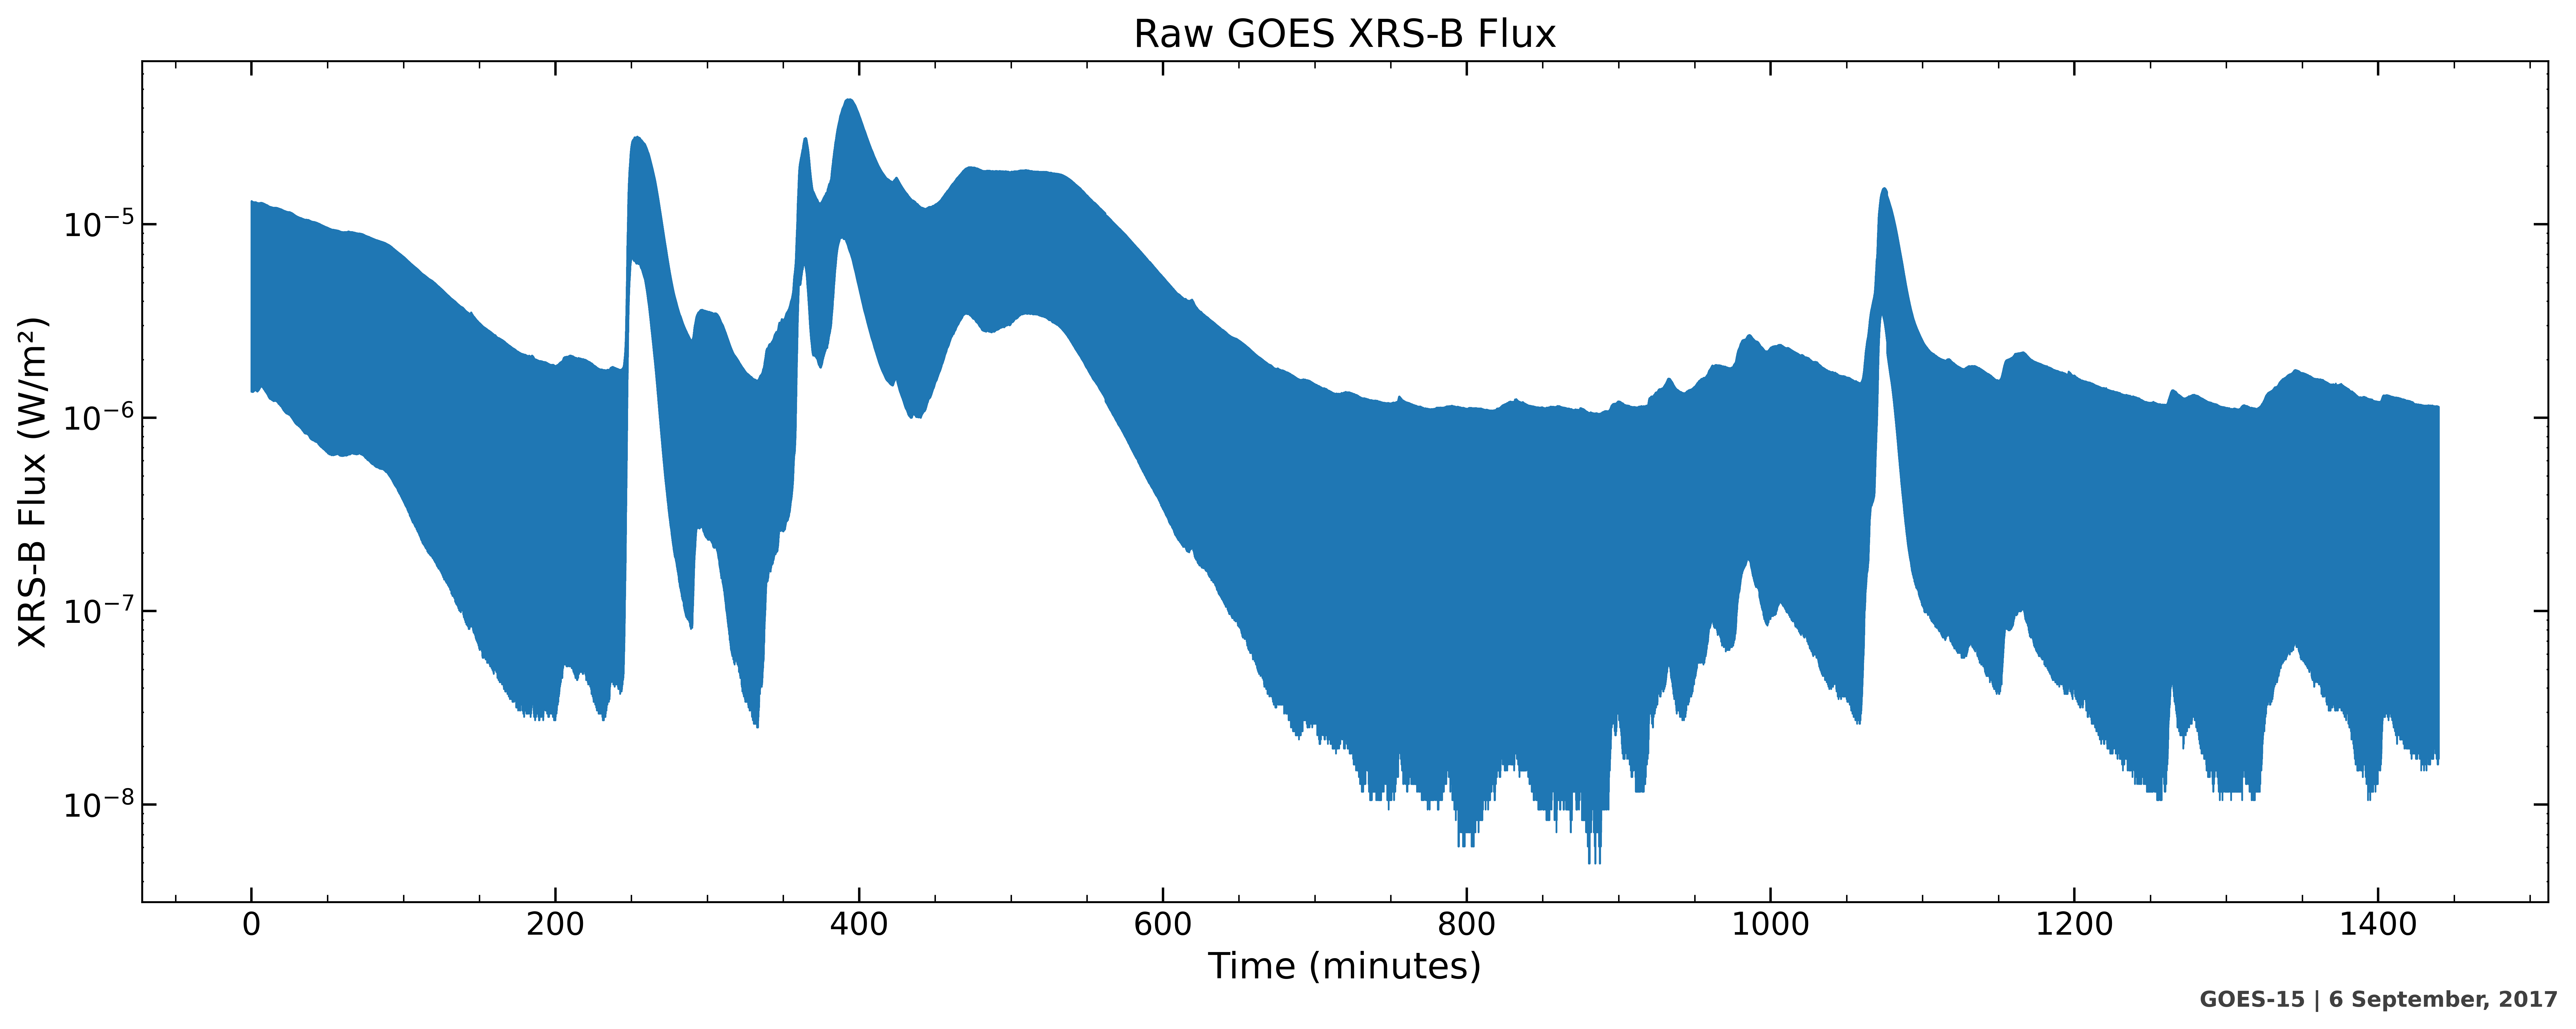


================ COARSE-GRAINING ====================

Coarse-graining scale: 5
N before coarse-graining: 42125
N after coarse-graining: 8425

================ SAMPLING ===========================

Median cadence: 10.240000009534924 seconds
Sampling frequency: 0.09765624990906788 Hz

================ HIGH-PASS FILTER ===================

Cutoff period: 300.0 minutes
Cutoff frequency: 5.555555555555556e-05 Hz
Normalized cutoff (Nyquist): 0.0011377777788372139

================ POWER SPECTRAL DENSITY =============


Peaks found in [5, 300] min range:
  period =     5.34 min | power = 1.4940e-01 | prominence = 0.606
  period =     5.55 min | power = 1.8381e-01 | prominence = 0.618
  period =     5.87 min | power = 1.2961e-01 | prominence = 0.432
  period =     6.19 min | power = 2.6317e-01 | prominence = 0.481
  period =     6.47 min | power = 4.1869e-01 | prominence = 1.100
  period =     6.99 min | power = 2.1475e-01 | prominence = 0.217
  period =     7.52 min | power = 4.1577e-01 | p


================ AUTOMATIC GROUPING =================

SSA-1: Trend  (component 1)
   → 1 component(s) | energy fraction = 0.545457

SSA-2: Oscillatory  [10^-1 scale]  (components 2–4)
   → 3 component(s) | energy fraction = 0.305691

SSA-3: Oscillatory  [10^-2 scale]  (components 5–10)
   → 6 component(s) | energy fraction = 0.121818

SSA-4: Oscillatory  [10^-3 scale]  (components 11–19)
   → 9 component(s) | energy fraction = 0.019609

SSA-5: Oscillatory  [10^-4 scale]  (components 20–47)
   → 28 component(s) | energy fraction = 0.006133

SSA-6: Noise / Residual  (components 48–984)
   → 937 component(s) | energy fraction = 0.001292


================ RECONSTRUCTION =====================

Reconstructed: SSA-1: Trend  (component 1)
Reconstructed: SSA-2: Oscillatory  [10^-1 scale]  (components 2–4)
Reconstructed: SSA-3: Oscillatory  [10^-2 scale]  (components 5–10)
Reconstructed: SSA-4: Oscillatory  [10^-3 scale]  (components 11–19)
Reconstructed: SSA-5: Oscillatory  [10^-4 scale]  (c

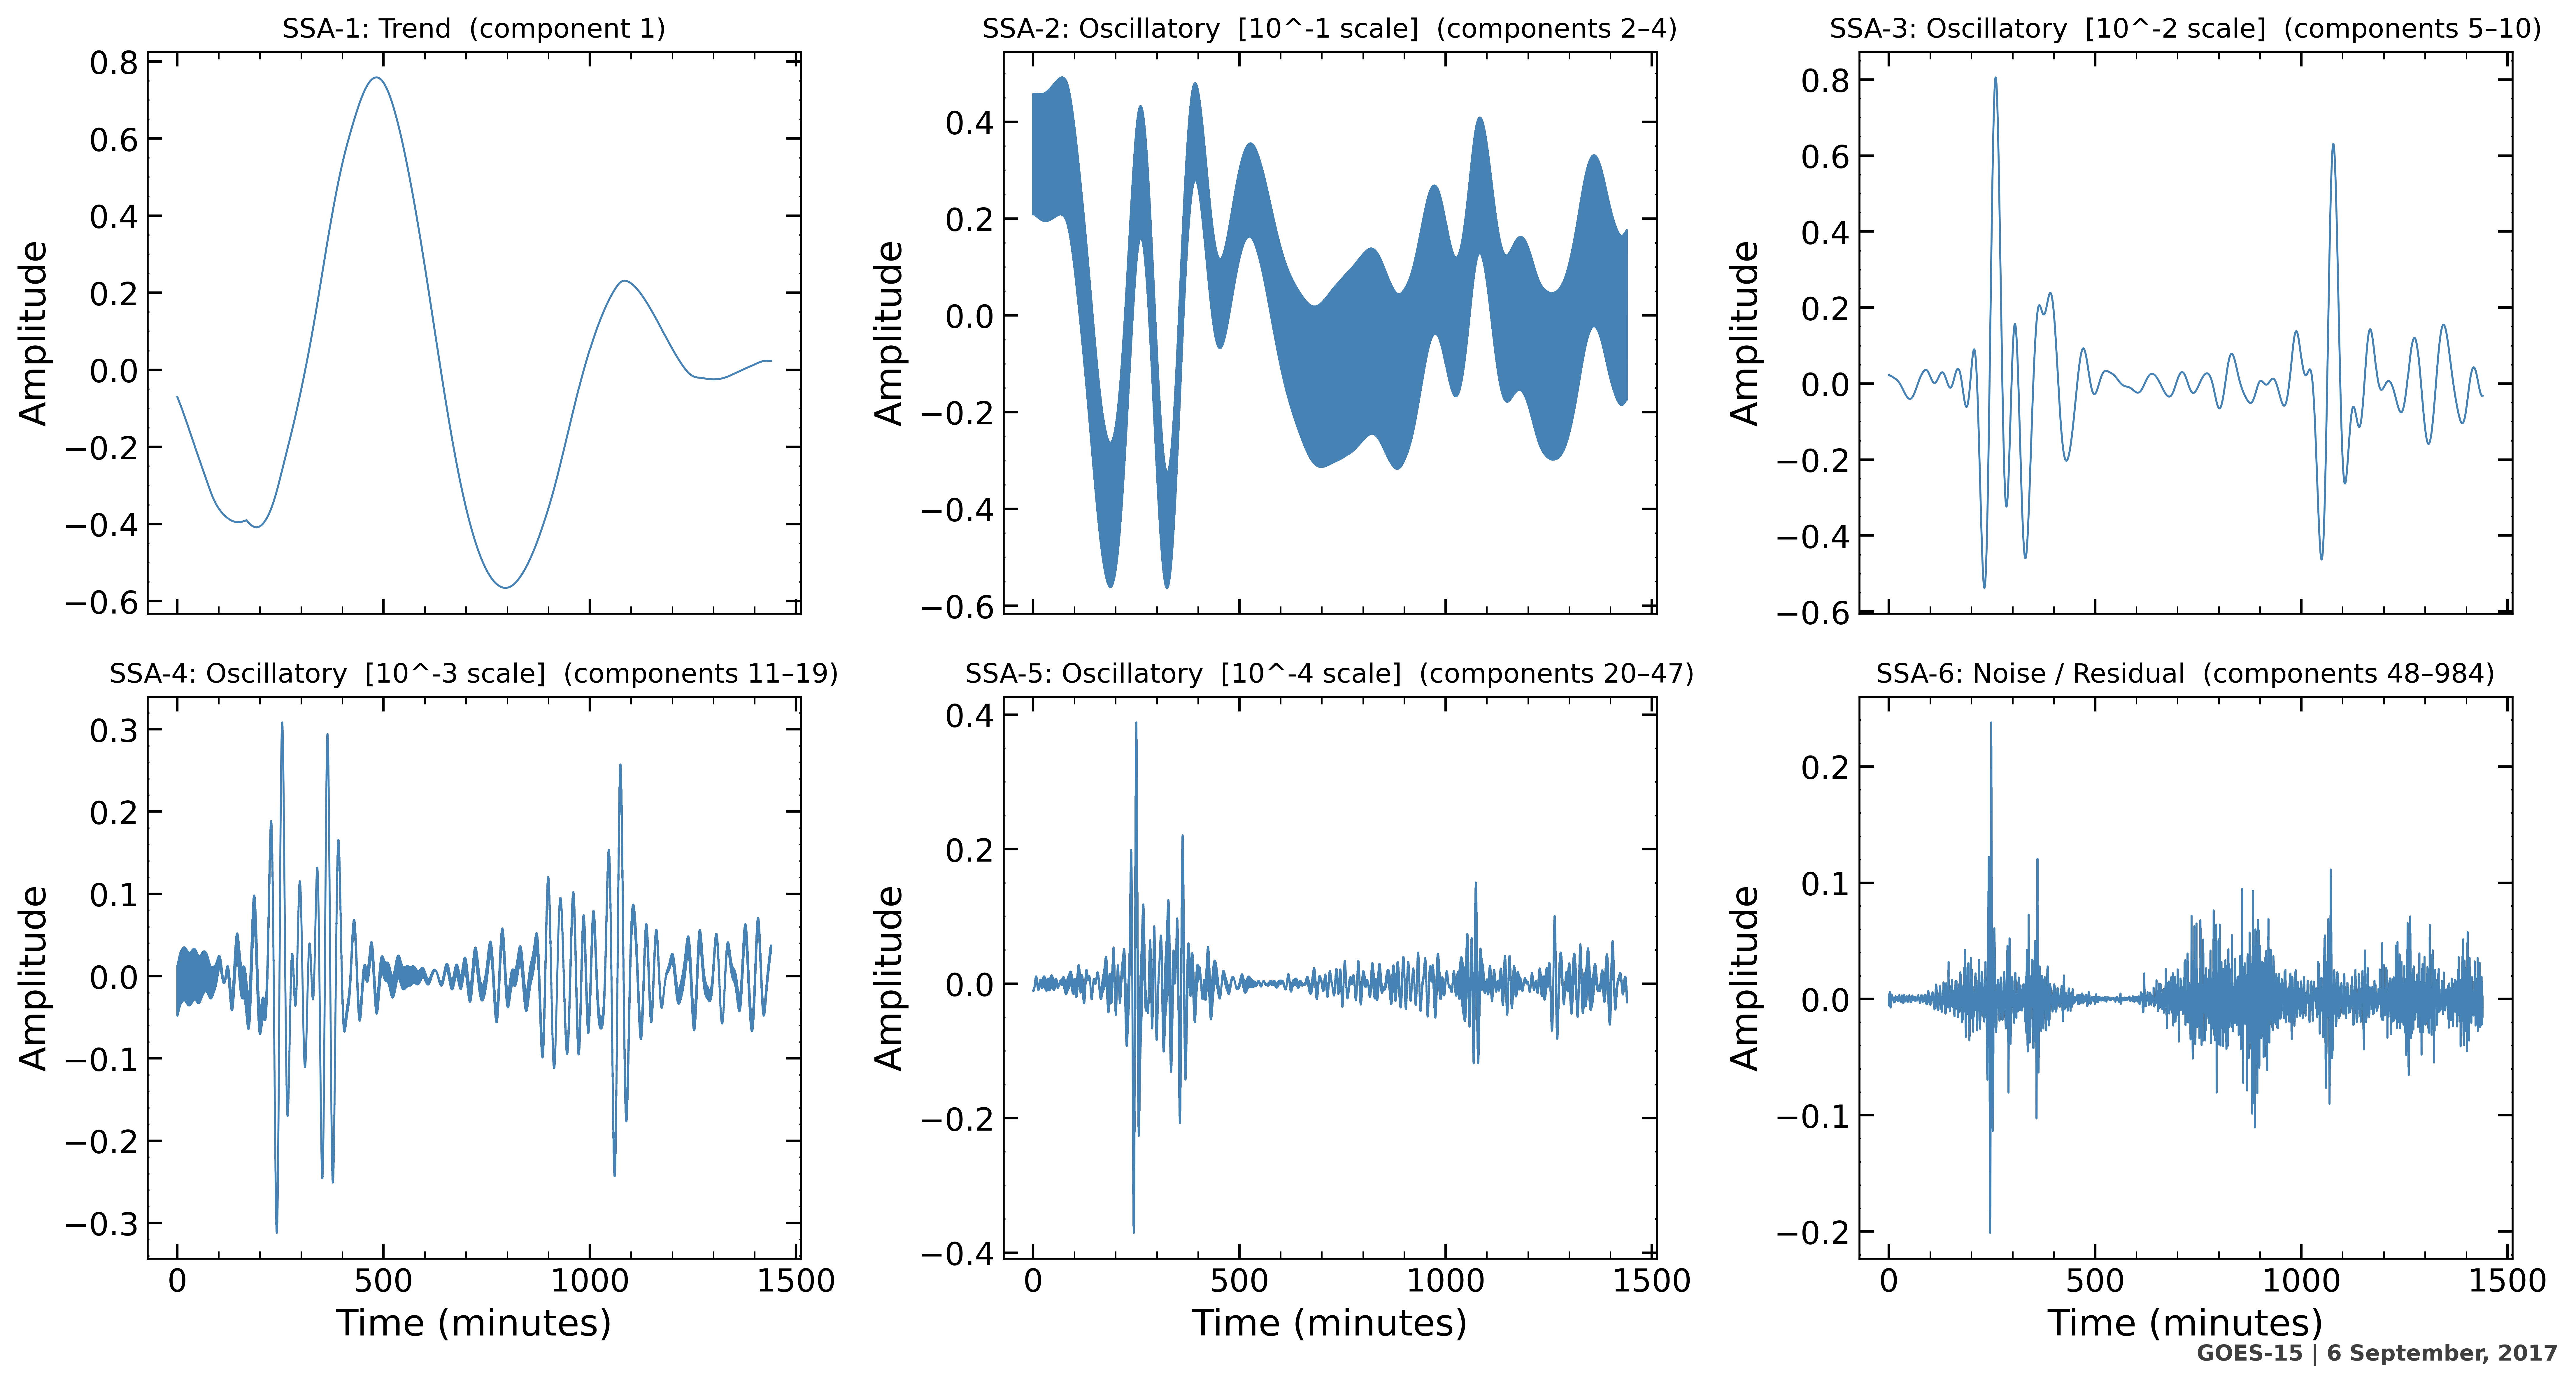


================ FINAL SUMMARY ======================

Number of samples N:    8425
Sampling interval:      10.240000009534924 seconds
Dominant PSD period:    139.81013346351682 minutes
Selected L:             984
Window duration:        167.93600015637276 minutes
Trajectory dimensions:  984 × 7442
Gram matrix dimensions: 984 × 984
Number of eigenvalues:  984
Number of SSA groups:   6

  SSA-1: Trend  (component 1)
    Energy fraction: 0.545457
  SSA-2: Oscillatory  [10^-1 scale]  (components 2–4)
    Energy fraction: 0.305691
  SSA-3: Oscillatory  [10^-2 scale]  (components 5–10)
    Energy fraction: 0.121818
  SSA-4: Oscillatory  [10^-3 scale]  (components 11–19)
    Energy fraction: 0.019609
  SSA-5: Oscillatory  [10^-4 scale]  (components 20–47)
    Energy fraction: 0.006133
  SSA-6: Noise / Residual  (components 48–984)
    Energy fraction: 0.001292

SSA NOISE ANALYSIS
Noise group: SSA-6: Noise / Residual  (components 48–984)
Samples: 8425

Running KDE...
  Robust scale      : 8.




Saved diagnostic summary CSV:
/content/SSA_components\SSA_noise_diagnostics_summary.csv

Saved numerical diagnostics:
/content/SSA_components\SSA_noise_diagnostics.csv

STATE DEPENDENCE OF SSA NOISE
Loaded SSA-1: 8425 samples
Loaded SSA-2: 8425 samples
Loaded SSA-3: 8425 samples
Loaded SSA-4: 8425 samples
Loaded SSA-5: 8425 samples
Loaded SSA-6: 8425 samples

Using SSA-6 (SSA-6: Noise / Residual  (components 48–984)) as the noise component.
State components to test against it: ['SSA-1', 'SSA-2', 'SSA-3', 'SSA-4', 'SSA-5']

Time-axis check passed for all 6 SSA components.

--------------------------------------------------------
SSA-1 vs SSA-6 (Noise)
--------------------------------------------------------
Valid samples              : 8425
Pearson r                  : -0.00001
Pearson p-value            : 9.99081e-01
Spearman rho               : 0.01671
Spearman p-value           : 1.25017e-01
Positive samples for log   : 1864
Log Pearson r             : -0.33692
Log Spearman rho     

In [ ]:
from scipy.stats import pearsonr, spearmanr
import os
from collections import defaultdict
from scipy.stats import gaussian_kde, norm, skew, kurtosis
from scipy.signal import butter, filtfilt, find_peaks
from scipy import signal
from astropy.io import fits
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.size": 14,
    "agg.path.chunksize": 10000,
    "axes.labelsize": 15,
    "axes.titlesize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "xtick.bottom": True,
    "ytick.left": True,
    "ytick.right": True,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.minor.size": 3,
    "ytick.minor.size": 0.7,
})


# USER INPUT

file_path = (
    r"C:\Users\mnncs\Downloads\SSA_flares\go1520131028.fits"
)

"""
file_path = "/content/drive/MyDrive/SSA fits files/go1520131028.fits"
CORRELATION_OUTPUT_FOLDER = "/content/drive/MyDrive/SSA fits files"
"""
OBSERVATION_LABEL = "GOES-15 | 28 October, 2013"


def add_observation_label(fig):

    fig.text(
        0.99, 0.01,
        OBSERVATION_LABEL,
        ha="right",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        alpha=0.75
    )


NOISE_FLOOR_EXPONENT = -4
RECON_CHUNK = 2000

# 1. LOAD FITS

hdul = fits.open(file_path)
print("\n================ FITS FILE STRUCTURE ================\n")
hdul.info()
data = hdul[2].data
print("\n================ AVAILABLE COLUMNS ==================\n")
print(data.columns)

# ============================================================
# 2. EXTRACT TIME + FLUX
# ============================================================

time = np.array(data[0][0]) / 60.0
flux = np.array(data[0][1])

# ============================================================
# 3. SPLIT XRS-A AND XRS-B
# ============================================================

flux = flux.reshape(2, -1)
xrsa = flux[0]
xrsb = flux[1]
signal_raw = xrsb


# ============================================================
# 4. REMOVE INVALID VALUES
# ============================================================

mask = (
    np.isfinite(time)
    & np.isfinite(signal_raw)
    & (signal_raw > 0)
)
time = time[mask]
signal_raw = signal_raw[mask]

print("\n================ DATA SUMMARY ========================\n")
print("Number of XRS-B samples:", len(signal_raw))
print("Time range:", time[0], "to", time[-1], "minutes")
print("XRS-B minimum:", np.min(signal_raw))
print("XRS-B maximum:", np.max(signal_raw))


# ============================================================
# 5. LOG TRANSFORMATION
# ============================================================

signal_log = np.log10(signal_raw)


# ============================================================
# 6. LINEAR DETREND
# ============================================================

signal_detrended = signal.detrend(signal_log, type="linear")

# ============================================================
# 7. RAW XRS-B PLOT   (PLOT 1)
# ============================================================

fig, ax = plt.subplots(figsize=(15, 6), dpi=600)
ax.plot(time, signal_raw, linewidth=0.7)
ax.set_yscale("log")
ax.set_xlabel("Time (minutes)")
ax.set_ylabel("XRS-B Flux (W/m²)")
ax.set_title("Raw GOES XRS-B Flux")
plt.tight_layout()
add_observation_label(fig)
plt.show()

# ============================================================
# 7B. COARSE-GRAINING (SCALE = 5)
# ============================================================

COARSE_SCALE = 5


def coarse_grain(x, scale):
    n_blocks = len(x) // scale
    x = x[: n_blocks * scale]
    return x.reshape(n_blocks, scale).mean(axis=1)


N_before_coarse = len(signal_detrended)
time = coarse_grain(time,            COARSE_SCALE)
signal_detrended = coarse_grain(signal_detrended, COARSE_SCALE)

print("\n================ COARSE-GRAINING ====================\n")
print("Coarse-graining scale:", COARSE_SCALE)
print("N before coarse-graining:", N_before_coarse)
print("N after coarse-graining:",  len(signal_detrended))


# ============================================================
# 8. SAMPLING INTERVAL
# ============================================================

dt_minutes = np.median(np.diff(time))
dt_seconds = dt_minutes * 60.0
Fs = 1.0 / dt_seconds

print("\n================ SAMPLING ===========================\n")
print("Median cadence:",     dt_seconds, "seconds")
print("Sampling frequency:", Fs,         "Hz")


# ============================================================
# 8B. HIGH-PASS FILTER TO REMOVE RESIDUAL FLARE TREND
# ============================================================

MAX_PERIOD = 300.0
MIN_PERIOD = 5.0

cutoff_freq_hz = 1.0 / (MAX_PERIOD * 60.0)
nyquist = Fs / 2.0
normalized_cutoff = min(cutoff_freq_hz / nyquist, 0.99)

butter_b, butter_a = butter(N=4, Wn=normalized_cutoff, btype="highpass")
signal_residual = filtfilt(butter_b, butter_a, signal_detrended)

print("\n================ HIGH-PASS FILTER ===================\n")
print("Cutoff period:",               MAX_PERIOD,        "minutes")
print("Cutoff frequency:",            cutoff_freq_hz,    "Hz")
print("Normalized cutoff (Nyquist):", normalized_cutoff)

# ============================================================
# 9. POWER SPECTRAL DENSITY (Welch)
# ============================================================

print("\n================ POWER SPECTRAL DENSITY =============\n")

nperseg = min(4096, len(signal_residual))
freq, psd = signal.welch(
    signal_residual,
    fs=Fs,
    window="hann",
    nperseg=nperseg,
    noverlap=None,
    detrend="constant",
    scaling="density",
)

valid_freq = freq > 0
freq = freq[valid_freq]
psd = psd[valid_freq]
period_minutes = 1.0 / freq / 60.0

valid = (
    np.isfinite(period_minutes)
    & np.isfinite(psd)
    & (period_minutes > 0)
    & (psd > 0)
)
period_minutes = period_minutes[valid]
freq = freq[valid]
psd = psd[valid]

# ============================================================
# 10. FIND DOMINANT LOCAL PEAK
# ============================================================

psd_mask = (period_minutes >= MIN_PERIOD) & (period_minutes <= MAX_PERIOD)
candidate_periods = period_minutes[psd_mask]
candidate_freq = freq[psd_mask]
candidate_psd = psd[psd_mask]

sort_order = np.argsort(candidate_periods)
sorted_periods = candidate_periods[sort_order]
sorted_freq = candidate_freq[sort_order]
sorted_psd = candidate_psd[sort_order]

peak_indices, peak_props = find_peaks(
    np.log10(sorted_psd), prominence=0.2
)

peak_periods = sorted_periods[peak_indices]
peak_freqs = sorted_freq[peak_indices]
peak_power = sorted_psd[peak_indices]
peak_prominence = peak_props["prominences"]

print(f"\nPeaks found in [{MIN_PERIOD:.0f}, {MAX_PERIOD:.0f}] min range:")
if len(peak_periods) == 0:
    print("  None found with prominence >= 0.2 dex.")
else:
    for p, pw, prom in zip(peak_periods, peak_power, peak_prominence):
        print(
            f"  period = {p:8.2f} min | power = {pw:.4e} | prominence = {prom:.3f}")

if len(peak_periods) > 0:
    best = np.argmax(peak_power)
    dominant_period = peak_periods[best]
    dominant_frequency = peak_freqs[best]
else:
    print(
        "  WARNING: no local peak passed the prominence threshold — "
        "falling back to argmax in range. Treat result with caution."
    )
    fallback_idx = np.argmax(sorted_psd)
    dominant_period = sorted_periods[fallback_idx]
    dominant_frequency = sorted_freq[fallback_idx]

print("\nDominant frequency:", dominant_frequency, "Hz")
print("Dominant period:   ", dominant_period,     "minutes")

# ============================================================
# 11. SSA WINDOW LENGTH L
# ============================================================

L = int(np.ceil(1.2 * dominant_period / dt_minutes))
N = len(signal_detrended)
L = min(L, int(0.45 * N))
L = max(L, 10)
if L % 2 != 0:
    L -= 1

K = N - L + 1

print("\n================ WINDOW LENGTH ======================\n")
print("N =",               N)
print("Dominant period =", dominant_period, "minutes")
print("Chosen L =",        L,               "samples")
print("Window duration =", L * dt_minutes,  "minutes")
print("K = N-L+1 =",       K)


# ============================================================
# 13. GRAM MATRIX
# ============================================================

print("\n================ GRAM MATRIX =========================\n")

windows = np.lib.stride_tricks.sliding_window_view(signal_detrended, L)
print("Logical trajectory matrix:", windows.shape)

G = np.zeros((L, L), dtype=np.float64)
CHUNK_SIZE = 5000

for start in range(0, K, CHUNK_SIZE):
    stop = min(start + CHUNK_SIZE, K)
    W = windows[start:stop]
    G += W.T @ W

G = (G + G.T) / 2.0
print("Gram matrix shape:", G.shape)


# ============================================================
# 14. EIGENDECOMPOSITION
# ============================================================

print("\n================ EIGENDECOMPOSITION =================\n")

eigenvalues, eigenvectors = np.linalg.eigh(G)
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]
eigenvalues = np.maximum(eigenvalues, 0)

print("Number of eigenvalues:", len(eigenvalues))


# ============================================================
# 15. ENERGY FRACTION
# ============================================================

energy_fraction = eigenvalues / np.sum(eigenvalues)
cumulative_energy = np.cumsum(energy_fraction)

print("\nFirst 20 eigenvalues:")
for i in range(min(20, L)):
    print(
        f"{i + 1:3d} | "
        f"λ = {eigenvalues[i]:.6e} | "
        f"Energy = {energy_fraction[i]:.6f}"
    )


fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(15, 12),
    dpi=600
)


ax1.loglog(
    period_minutes,
    psd,
    linewidth=0.8,
    label="Welch PSD (high-pass residual)"
)

if len(peak_periods) > 0:
    ax1.scatter(
        peak_periods,
        peak_power,
        marker="x",
        s=50,
        color="black",
        zorder=5,
        label="Detected local peaks"
    )

ax1.axvline(
    dominant_period,
    linestyle="--",
    linewidth=1.2,
    color="red",
    label=f"Chosen dominant period = {dominant_period:.2f} min"
)

ax1.set_xlabel("Period (minutes)")
ax1.set_ylabel("Power spectral density")
ax1.set_title("Welch PSD of High-Pass-Filtered XRS-B Residual")
ax1.legend()

N_SCREE_POINTS = 18
component_number = np.arange(1, L + 1)
eigenvalues_norm = eigenvalues / eigenvalues[0]

log_idx = np.round(
    np.logspace(0, np.log10(L), num=N_SCREE_POINTS)
).astype(int)

log_idx = np.concatenate(([1], log_idx, [L]))
log_idx = np.clip(log_idx, 1, L)
log_idx = np.unique(log_idx)

plot_cn = component_number[log_idx - 1]
plot_enorm = eigenvalues_norm[log_idx - 1]

ax2.plot(
    plot_cn,
    plot_enorm,
    linewidth=0.8,
    marker="o",
    markersize=5
)

ax2.set_yticks(np.arange(0, 1.1, 0.1))
ax2.set_xlabel("Eigenvalue number")
ax2.set_ylabel(r"Normalized eigenvalue  $\lambda_i / \lambda_1$")
ax2.set_title(
    f"Normalized SSA Eigenvalue Spectrum — linear scale "
    f"({len(plot_cn)} of {L} points)"
)

ax2.set_xlim(-5, L + 10)
ax2.set_ylim(-0.05, 1.05)
plt.tight_layout()
add_observation_label(fig)
plt.show()

# ============================================================
# 17. AUTOMATIC MAGNITUDE-BASED SSA GROUPING
# ============================================================

print("\n================ AUTOMATIC GROUPING =================\n")

groups = []

# ── Group 1: Trend ─────────────────────────────────────────────────────
groups.append(("SSA-1: Trend  (component 1)", [0]))

# ── Compute floor(log10) for components 2 … L ──────────────────────────
with np.errstate(divide="ignore"):
    log10_norm = np.where(
        eigenvalues_norm[1:] > 0,
        np.log10(eigenvalues_norm[1:]),
        -999.0,
    )

floors = np.floor(log10_norm).astype(int)   # length = L - 1

floor_to_indices = defaultdict(list)
for rel_idx, floor_val in enumerate(floors):
    floor_to_indices[floor_val].append(rel_idx + 1)   # 0-based index

# ── Build oscillatory groups (most energetic first) ────────────────────
noise_indices = []

for fv in sorted(floor_to_indices.keys(), reverse=True):
    idxs = floor_to_indices[fv]

    if fv >= NOISE_FLOOR_EXPONENT:
        c_lo = idxs[0] + 1
        c_hi = idxs[-1] + 1
        span = f"components {c_lo}–{c_hi}" if len(
            idxs) > 1 else f"component {c_lo}"
        label = (
            f"SSA-{len(groups) + 1}: Oscillatory  "
            f"[10^{fv} scale]  ({span})"
        )
        groups.append((label, idxs))
    else:
        noise_indices.extend(idxs)

# ── Noise group ─────────────────────────────────────────────────────────
if noise_indices:
    noise_indices.sort()
    c_lo = noise_indices[0] + 1
    c_hi = noise_indices[-1] + 1
    label = (
        f"SSA-{len(groups) + 1}: Noise / Residual  "
        f"(components {c_lo}–{c_hi})"
    )
    groups.append((label, noise_indices))

# ── Summary ─────────────────────────────────────────────────────────────
for gname, gidxs in groups:
    ef = np.sum(energy_fraction[gidxs])
    print(
        f"{gname}\n"
        f"   → {len(gidxs)} component(s) | energy fraction = {ef:.6f}\n"
    )


# ============================================================
# 18. RECONSTRUCTION HELPER
# ============================================================

def reconstruct_group(idx_list, L, K, windows, eigenvectors,
                      chunk=RECON_CHUNK):

    Ug = eigenvectors[:, idx_list]    # (L, m)
    N_series = L + K - 1
    sums = np.zeros(N_series, dtype=np.float64)
    counts = np.zeros(N_series, dtype=np.float64)
    l_arr = np.arange(L)

    for start in range(0, K, chunk):
        stop = min(start + chunk, K)
        W_chunk = windows[start:stop]              # (chunk, L)
        A_chunk = W_chunk @ Ug                     # (chunk, m)
        X_chunk = Ug @ A_chunk.T                   # (L, chunk)
        k_arr = np.arange(start, stop)
        s = l_arr[:, None] + k_arr[None, :]  # anti-diagonal indices

        sums += np.bincount(s.ravel(),
                            weights=X_chunk.ravel(),
                            minlength=N_series)
        counts += np.bincount(s.ravel(), minlength=N_series)

    return sums / counts


# ============================================================
# 19. RECONSTRUCT EACH GROUP
# ============================================================

print("\n================ RECONSTRUCTION =====================\n")

reconstructed = []
for gname, gidxs in groups:
    comp = reconstruct_group(gidxs, L, K, windows, eigenvectors)
    reconstructed.append(comp)
    print(f"Reconstructed: {gname}")

recon_sum = sum(reconstructed)
max_err = np.max(np.abs(recon_sum - signal_detrended))
print(f"\nMax |reconstruction - original|: {max_err:.6e}")


# ============================================================
# 20. SAVE EACH SSA GROUP TO CSV
# ============================================================

output_folder = "/content/SSA_components"
os.makedirs(output_folder, exist_ok=True)

for (gname, _), comp in zip(groups, reconstructed):
    ssa_name = gname.split(":")[0].replace("-", "")
    df = pd.DataFrame({
        "Time (minutes)": time,
        "Amplitude": comp
    })
    filename = os.path.join(output_folder, f"{ssa_name}.csv")
    df.to_csv(filename, index=False)
    print(f"Saved: {filename}")

# ============================================================
# 21. SSA DECOMPOSITION PLOTS   (3 × 2 layout)
# ============================================================
n_groups = len(groups)
n_cols = 3
n_rows = int(np.ceil(n_groups / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(15, 8),
    dpi=600,
    sharex=True,
)

axes = np.ravel(axes)

for ax, (gname, _), comp in zip(axes, groups, reconstructed):
    ax.plot(
        time,
        comp,
        color="steelblue",
        linewidth=0.8
    )

    ax.set_ylabel("Amplitude")
    ax.set_title(gname, fontsize=11)   # smaller title

for ax in axes[-n_cols:]:
    ax.set_xlabel("Time (minutes)")

for ax in axes[n_groups:]:
    ax.remove()

plt.tight_layout()
add_observation_label(fig)
plt.show()
# ============================================================
# 22. FINAL SUMMARY
# ============================================================

print("\n================ FINAL SUMMARY ======================\n")
print("Number of samples N:   ", N)
print("Sampling interval:     ", dt_seconds, "seconds")
print("Dominant PSD period:   ", dominant_period, "minutes")
print("Selected L:            ", L)
print("Window duration:       ", L * dt_minutes, "minutes")
print("Trajectory dimensions: ", L, "×", K)
print("Gram matrix dimensions:", L, "×", L)
print("Number of eigenvalues: ", len(eigenvalues))
print("Number of SSA groups:  ", n_groups)
print()
for gname, gidxs in groups:
    ef = np.sum(energy_fraction[gidxs])
    print(f"  {gname}")
    print(f"    Energy fraction: {ef:.6f}")


# ============================================================
# 23. NOISE COMPONENT DIAGNOSTICS
# ============================================================

NOISE_OUTPUT_FOLDER = "/content/SSA_components"
os.makedirs(NOISE_OUTPUT_FOLDER, exist_ok=True)


# ============================================================
# 23A. IDENTIFY NOISE / RESIDUAL GROUP
# ============================================================
noise_group_index = None
for i, (gname, gidxs) in enumerate(groups):
    if "Noise" in gname or "Residual" in gname:
        noise_group_index = i
        break
if noise_group_index is None:
    noise_group_index = len(groups) - 1
    print(f"[WARN] No explicit Noise/Residual group found. "
          f"Using last group as proxy: {groups[noise_group_index][0]}")

noise_label = groups[noise_group_index][0]          # ← untouched
noise_component = np.asarray(
    reconstructed[noise_group_index], dtype=np.float64)
noise_time = np.asarray(time, dtype=np.float64)    # ← full length, no mask

if not np.all(np.isfinite(noise_component)):
    n_bad = np.sum(~np.isfinite(noise_component))
    print(
        f"[WARN] {n_bad} non-finite value(s) in noise component — replaced with 0.")
    noise_component = np.where(np.isfinite(
        noise_component), noise_component, 0.0)


print("\n========================================================")
print("SSA NOISE ANALYSIS")
print("========================================================")
print("Noise group:", noise_label)
print("Samples:", len(noise_component))


# ============================================================
# 23B. BASIC DISTRIBUTION STATISTICS
# ============================================================

noise_mean = float(np.mean(noise_component))
noise_std = float(np.std(noise_component, ddof=1))
noise_skewness = float(skew(noise_component, bias=False))
noise_kurtosis = float(kurtosis(noise_component, bias=False))

if noise_std <= 0:
    raise ValueError("SSA noise component has zero variance.")


# ============================================================
# 23C. KERNEL DENSITY ESTIMATION  (fixed)
# ============================================================


print("\nRunning KDE...")

# Robust bandwidth: Scott's rule using IQR-based scale
n_noise = len(noise_component)
iqr_bw = np.subtract(*np.percentile(noise_component, [75, 25]))
robust_scale = min(noise_std, iqr_bw / 1.349)          # Silverman robust scale
bw_scott = robust_scale * n_noise ** (-1.0 / 5.0)  # Scott exponent

# scipy gaussian_kde takes bw as a factor on the data std, so convert
bw_factor = bw_scott / noise_std if noise_std > 0 else "scott"

kde = gaussian_kde(noise_component, bw_method=bw_factor)


x_lo = np.percentile(noise_component, 0.1) - 2.0 * bw_scott
x_hi = np.percentile(noise_component, 99.9) + 2.0 * bw_scott
x_grid = np.linspace(x_lo, x_hi, 600)

kde_pdf = kde(x_grid)
gaussian_pdf = norm.pdf(x_grid, loc=noise_mean, scale=noise_std)

print(f"  Robust scale      : {robust_scale:.4e}")
print(f"  Scott bandwidth   : {bw_scott:.4e}")
print(f"  KDE bw_factor     : {bw_factor:.4f}")


# ============================================================
# 23D. SPECTRAL DECAY
# ============================================================

print("Running spectral-decay analysis...")

nperseg = min(2048, n_noise)
if nperseg < 64:
    raise ValueError("Noise component is too short for reliable PSD analysis.")

freq_noise, psd_noise = signal.welch(
    noise_component,
    fs=Fs,
    window="hann",
    nperseg=nperseg,
    noverlap=nperseg // 2,
    detrend="constant",
    scaling="density",
)

valid_psd = (
    (freq_noise > 0)
    & (freq_noise < 0.45 * Fs)
    & np.isfinite(psd_noise)
    & (psd_noise > 0)
)
freq_plot = freq_noise[valid_psd]
psd_plot = psd_noise[valid_psd]


# ============================================================
# 23E. POWER-LAW FIT
# ============================================================

if len(freq_plot) < 10:
    raise ValueError("Too few valid PSD points for spectral-decay fitting.")

f_low = np.percentile(freq_plot, 5)
f_high = np.percentile(freq_plot, 80)

fit_mask = (freq_plot >= f_low) & (freq_plot <= f_high) & (psd_plot > 0)
fit_freq = freq_plot[fit_mask]
fit_psd = psd_plot[fit_mask]

if len(fit_freq) < 5:
    raise ValueError("Too few points in the spectral fitting range.")

log_freq = np.log10(fit_freq)
log_psd = np.log10(fit_psd)

slope, intercept = np.polyfit(log_freq, log_psd, 1)
spectral_beta = -slope

log_psd_fit = slope * log_freq + intercept
ss_res = np.sum((log_psd - log_psd_fit) ** 2)
ss_tot = np.sum((log_psd - np.mean(log_psd)) ** 2)
spectral_r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

fit_line = 10 ** (slope * np.log10(freq_plot) + intercept)


# ============================================================
# 23F. SPECTRAL CLASSIFICATION
# ============================================================

if spectral_beta < -0.3:
    spectral_type = "Blue / anti-correlated noise"
elif abs(spectral_beta) <= 0.3:
    spectral_type = "Approximately white noise"
elif spectral_beta < 1.5:
    spectral_type = "Pink / 1/f-like noise"
elif spectral_beta < 2.5:
    spectral_type = "Red / Brownian-like noise"
elif spectral_beta < 3.5:
    spectral_type = "Black / steep noise"
else:
    spectral_type = "Very steep power-law noise"


# ============================================================
# 23G. STABILITY ALPHA — QUANTILE REGRESSION APPROACH  (fixed)
# ============================================================


print("Running stability alpha estimation (ECF method)...")


def estimate_alpha_ecf(x, n_t=200, t_lo=0.01, t_hi=2.0):
    x = np.asarray(x, dtype=np.float64)
    x = x - np.median(x)                       # centre (remove location)

    t_grid = np.linspace(t_lo, t_hi, n_t)
    ecf_mod = np.array([np.abs(np.mean(np.exp(1j * t * x))) for t in t_grid])

    valid = (ecf_mod > 1e-6) & (ecf_mod < 1.0 - 1e-6)
    if np.sum(valid) < 20:
        return np.nan, np.nan

    t_v = t_grid[valid]
    ecf_v = ecf_mod[valid]

    # y = log(-log(|φ(t)|)) = α·log(t) + C
    log_t = np.log(t_v)
    log_nll = np.log(-np.log(ecf_v))           # negative log-likelihood proxy

    # Weighted least-squares: weight by ecf so noisy small values matter less
    w = ecf_v
    w = w / w.sum()

    # Weighted polyfit
    A = np.column_stack([log_t, np.ones_like(log_t)])
    W = np.diag(w)
    coeff, *_ = np.linalg.lstsq(A.T @ W @ A, A.T @ W @ log_nll, rcond=None)
    alpha_hat = float(np.clip(coeff[0], 0.1, 2.0))

    # R²
    fitted = coeff[0] * log_t + coeff[1]
    ss_res = np.sum(w * (log_nll - fitted) ** 2)
    ss_tot = np.sum(w * (log_nll - np.average(log_nll, weights=w)) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return alpha_hat, r2


alpha_ecf, alpha_ecf_r2 = estimate_alpha_ecf(noise_component)

print(f"  ECF α estimate : {alpha_ecf:.4f}  (R² = {alpha_ecf_r2:.4f})")

# ── Quantile-based cross-check (Fama–Roll 1971) ─────────────────────────

q05, q25, q50, q75, q95 = np.percentile(noise_component, [5, 25, 50, 75, 95])
iqr = q75 - q25
spread90 = q95 - q05

if iqr > 0:
    v_alpha = spread90 / iqr
else:
    v_alpha = np.nan


VA_TABLE = np.array([2.4388, 2.5120, 2.6080, 2.7369, 2.9115,
                     3.1480, 3.4602, 3.8695, 4.4019, 5.0191,
                     5.6812, 6.2095, 6.6273, 6.9256, 7.1013])
ALPHA_TABLE = np.array([2.0,    1.9,    1.8,    1.7,    1.6,
                        1.5,    1.4,    1.3,    1.2,    1.1,
                        1.0,    0.9,    0.8,    0.7,    0.6])


VA_ASC = VA_TABLE[::-1]       # 7.10 → 2.44  … wait, that's decreasing.

if np.isfinite(v_alpha):
    v_clamped = float(np.clip(v_alpha, VA_TABLE[0], VA_TABLE[-1]))
    alpha_quantile = float(np.interp(v_clamped, VA_TABLE, ALPHA_TABLE))
else:
    alpha_quantile = np.nan

print(f"  Quantile ratio : v_α = {v_alpha:.4f}")
print(f"  Quantile α     : {alpha_quantile:.4f}")

# ── Best estimate: prefer ECF if R² is reliable ─────────────────────────
if np.isfinite(alpha_ecf) and np.isfinite(alpha_ecf_r2) and alpha_ecf_r2 > 0.7:
    alpha_estimate = alpha_ecf
    alpha_method_used = f"ECF regression (R²={alpha_ecf_r2:.3f})"
elif np.isfinite(alpha_quantile):
    alpha_estimate = alpha_quantile
    alpha_method_used = "Fama–Roll quantile ratio"
else:
    alpha_estimate = np.nan
    alpha_method_used = "Not estimable"

print(f"  ─ Using: {alpha_method_used}")
print(f"  ─ Final α = {alpha_estimate:.4f}")


# ── Quantile-based asymmetry ─────────────────────────────────────────────
stable_skewness = (q95 + q05 - 2.0 * q50) / \
    spread90 if spread90 > 0 else np.nan


# ============================================================
# 23H. INTERPRETATIONS
# ============================================================

if not np.isfinite(alpha_estimate):
    stability_interpretation = "Unable to estimate"
elif alpha_estimate >= 1.95:
    stability_interpretation = "Near-Gaussian / light-tailed"
elif alpha_estimate >= 1.5:
    stability_interpretation = "Moderately heavy-tailed"
elif alpha_estimate >= 1.0:
    stability_interpretation = "Heavy-tailed"
else:
    stability_interpretation = "Very heavy-tailed"

if not np.isfinite(stable_skewness):
    skew_interpretation = "Unable to estimate"
elif stable_skewness > 0.1:
    skew_interpretation = "Right-skewed"
elif stable_skewness < -0.1:
    skew_interpretation = "Left-skewed"
else:
    skew_interpretation = "Approximately symmetric"


# ============================================================
# 23I. PRINT RESULTS
# ============================================================

print("\n========================================================")
print("SSA NOISE DIAGNOSTICS")
print("========================================================")

print("\n--- DISTRIBUTION ---")
print(f"Mean                  : {noise_mean:.6e}")
print(f"Standard deviation    : {noise_std:.6e}")
print(f"Sample skewness       : {noise_skewness:.5f}")
print(f"Excess kurtosis       : {noise_kurtosis:.5f}")

print("\n--- SPECTRAL DECAY ---")
print("Model                 : PSD ∝ f^(-β)")
print(f"Spectral decay β      : {spectral_beta:.5f}")
print(f"Log-log R²            : {spectral_r2:.5f}")
print(f"Classification        : {spectral_type}")

print("\n--- STABILITY / SKEWNESS ---")
print(f"Quantile ratio v_α    : {v_alpha:.5f}")
print(f"Quantile α            : {alpha_quantile:.5f}")
print(f"ECF α                 : {alpha_ecf:.5f}  (R² = {alpha_ecf_r2:.4f})")
print(f"Method used           : {alpha_method_used}")
print(f"Final α estimate      : {alpha_estimate:.5f}")
print(f"Stability interpretation: {stability_interpretation}")
print(f"Quantile skewness     : {stable_skewness:.5f}")
print(f"Skewness interpretation: {skew_interpretation}")

# ============================================================
# 23J. DIAGNOSTIC FIGURE
# ============================================================

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5.5),
    dpi=600
)


# KDE panel
ax = axes[0]

ax.hist(
    noise_component,
    bins=80,
    density=True,
    alpha=0.35,
    color="steelblue",
    label="Histogram"
)

ax.plot(
    x_grid,
    kde_pdf,
    linewidth=1.8,
    color="firebrick",
    label="KDE (robust bw)"
)

ax.plot(
    x_grid,
    gaussian_pdf,
    linestyle="--",
    linewidth=1.4,
    color="green",
    label="Gaussian fit"
)

# Mark the KDE peak
kde_peak_x = x_grid[np.argmax(kde_pdf)]
kde_peak_y = np.max(kde_pdf)

ax.axvline(
    kde_peak_x,
    linestyle=":",
    linewidth=0.9,
    color="navy",
    alpha=0.6
)

ax.set_xlabel("Amplitude")
ax.set_ylabel("Probability density")
ax.set_title("Noise Amplitude Distribution")
ax.set_xlim(x_lo, x_hi)
ax.legend()


# Noise time series panel
ax = axes[1]

ax.plot(
    noise_time,
    noise_component,
    linewidth=0.5
)

ax.axhline(
    noise_mean,
    linestyle="--",
    linewidth=1.0,
    label="Mean"
)

ax.set_xlabel("Time (minutes)")
ax.set_ylabel("Amplitude")
ax.set_title(f"{noise_label} Time Series")
ax.legend()


# PSD panel
ax = axes[2]

ax.loglog(
    freq_plot,
    psd_plot,
    linewidth=0.8,
    label="Welch PSD"
)

ax.loglog(
    freq_plot,
    fit_line,
    linestyle="--",
    linewidth=1.4,
    label=f"β = {spectral_beta:.3f}"
)

ax.axvline(
    f_low,
    linestyle=":",
    linewidth=0.8,
    color="gray"
)

ax.axvline(
    f_high,
    linestyle=":",
    linewidth=0.8,
    color="gray"
)

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD")
ax.set_title(f"Spectral Decay — {spectral_type}")
ax.legend()


plt.suptitle(
    f"SSA Noise Diagnostics — {noise_label}",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
add_observation_label(fig)
plt.show()
plt.close(fig)

# ============================================================
# 23K. SAVE SUMMARY TO CSV
# ============================================================

summary_data = {
    "Noise component": noise_label,
    "Mean": noise_mean,
    "Std": noise_std,
    "Skewness": noise_skewness,
    "Excess kurtosis": noise_kurtosis,
    "Spectral beta": spectral_beta,
    "Spectral R2": spectral_r2,
    "Noise type": spectral_type,
    "Quantile v_alpha": v_alpha,
    "Quantile alpha": alpha_quantile,
    "ECF alpha": alpha_ecf,
    "ECF alpha R2": alpha_ecf_r2,
    "Alpha method": alpha_method_used,
    "Final alpha": alpha_estimate,
    "Tail interpretation": stability_interpretation,
    "Quantile skewness": stable_skewness,
    "Symmetry interpretation": skew_interpretation
}

summary_df = pd.DataFrame([summary_data])

summary_csv_path = os.path.join(
    NOISE_OUTPUT_FOLDER,
    "SSA_noise_diagnostics_summary.csv"
)

summary_df.to_csv(
    summary_csv_path,
    index=False
)

print("\nSaved diagnostic summary CSV:")
print(summary_csv_path)

# ============================================================
# 23L. SAVE NUMERICAL RESULTS
# ============================================================

noise_results = pd.DataFrame({
    "Parameter": [
        "SSA component",
        "N samples",
        "Mean",
        "Standard deviation",
        "Sample skewness",
        "Excess kurtosis",
        "Spectral decay beta",
        "Spectral R squared",
        "Spectral noise type",
        "Quantile ratio v_alpha",
        "Quantile alpha",
        "ECF alpha",
        "ECF alpha R2",
        "Alpha method used",
        "Final alpha estimate",
        "Stability interpretation",
        "Quantile skewness",
        "Skewness interpretation",
    ],
    "Value": [
        noise_label,
        len(noise_component),
        noise_mean,
        noise_std,
        noise_skewness,
        noise_kurtosis,
        spectral_beta,
        spectral_r2,
        spectral_type,
        v_alpha,
        alpha_quantile,
        alpha_ecf,
        alpha_ecf_r2,
        alpha_method_used,
        alpha_estimate,
        stability_interpretation,
        stable_skewness,
        skew_interpretation,
    ]
})

noise_results_path = os.path.join(
    NOISE_OUTPUT_FOLDER, "SSA_noise_diagnostics.csv")
noise_results.to_csv(noise_results_path, index=False)

print("\nSaved numerical diagnostics:")
print(noise_results_path)

# ============================================================
# 24. STATE DEPENDENCE OF SSA NOISE
# ============================================================


print("\n========================================================")
print("STATE DEPENDENCE OF SSA NOISE")
print("========================================================")

# =======================================================
# 24A. INPUT / OUTPUT LOCATION
# ============================================================

SSA_FOLDER = "/content/SSA_components"
STATE_OUTPUT_FOLDER = os.path.join(
    SSA_FOLDER,
    "state_dependence"
)

os.makedirs(
    STATE_OUTPUT_FOLDER,
    exist_ok=True
)


# ============================================================
# 24B. LOAD SSA COMPONENTS  (dynamic — matches however many
#      groups Section 17 actually produced for this file)
# ============================================================

n_groups_disk = len(groups)                 # authoritative count for this run
NOISE_COMPONENT_NUMBER = noise_group_index + 1   # 1-indexed, from Section 23A
STATE_COMPONENT_NUMBERS = [
    i for i in range(1, n_groups_disk + 1)
    if i != NOISE_COMPONENT_NUMBER
]

ssa_components = {}

for i in range(1, n_groups_disk + 1):

    filename = os.path.join(
        SSA_FOLDER,
        f"SSA{i}.csv"
    )

    if not os.path.exists(filename):
        raise FileNotFoundError(
            f"Could not find {filename}"
        )

    df = pd.read_csv(filename)

    required_columns = [
        "Time (minutes)",
        "Amplitude"
    ]

    for col in required_columns:
        if col not in df.columns:
            raise ValueError(
                f"{filename} does not contain "
                f"required column '{col}'"
            )

    ssa_components[i] = {
        "time": df["Time (minutes)"].to_numpy(
            dtype=float
        ),
        "amplitude": df["Amplitude"].to_numpy(
            dtype=float
        )
    }

    print(
        f"Loaded SSA-{i}: "
        f"{len(ssa_components[i]['amplitude'])} samples"
    )


# ============================================================
# 24C. USE THE ACTUAL NOISE GROUP (from Section 23A), NOT A
#      HARDCODED "SSA-6" — the noise group can land anywhere
#      depending on how many groups this file produced.
# ============================================================

noise_time_csv = ssa_components[NOISE_COMPONENT_NUMBER]["time"]
noise = ssa_components[NOISE_COMPONENT_NUMBER]["amplitude"]

print(
    f"\nUsing SSA-{NOISE_COMPONENT_NUMBER} ({noise_label}) as the noise component.")
print(f"State components to test against it: "
      f"{['SSA-' + str(i) for i in STATE_COMPONENT_NUMBERS]}")


# ============================================================
# 24D. CHECK TIME AXIS CONSISTENCY
# ============================================================

for i in STATE_COMPONENT_NUMBERS:

    component_time = ssa_components[i]["time"]

    if len(component_time) != len(noise_time_csv):

        raise ValueError(
            f"SSA-{i} and SSA-{NOISE_COMPONENT_NUMBER} have different lengths: "
            f"{len(component_time)} vs {len(noise_time_csv)}"
        )

    if not np.allclose(
        component_time,
        noise_time_csv,
        rtol=0,
        atol=1e-8
    ):

        raise ValueError(
            f"Time axes of SSA-{i} and SSA-{NOISE_COMPONENT_NUMBER} do not match."
        )


print(f"\nTime-axis check passed for all {n_groups_disk} SSA components.")


# ============================================================
# 24E. RESULTS TABLE
# ============================================================

state_dependence_results = []

# ============================================================
# 24F. EVERY NON-NOISE GROUP AGAINST THE NOISE GROUP
# ============================================================
n_state_components = len(STATE_COMPONENT_NUMBERS)

fig, axes = plt.subplots(
    n_state_components,
    2,
    figsize=(15, 5 * n_state_components),
    dpi=600,
    squeeze=False
)
for plot_row, component_number in enumerate(STATE_COMPONENT_NUMBERS):

    state = ssa_components[component_number]["amplitude"]
    noise = ssa_components[NOISE_COMPONENT_NUMBER]["amplitude"]
    valid = (
        np.isfinite(state)
        & np.isfinite(noise)
    )

    state_valid = state[valid]
    noise_valid = noise[valid]

    if len(state_valid) < 10:

        print(
            f"WARNING: SSA-{component_number} has too few "
            "valid samples."
        )

        continue

    # ========================================================
    # LINEAR-SPACE CORRELATIONS
    # ========================================================

    pearson_r, pearson_p = pearsonr(
        state_valid,
        noise_valid
    )

    spearman_r, spearman_p = spearmanr(
        state_valid,
        noise_valid
    )

    # ========================================================
    # LOG-SPACE DATA
    # ========================================================

    positive_mask = (
        np.isfinite(state)
        & np.isfinite(noise)
        & (state > 0)
        & (noise > 0)
    )

    state_positive = state[positive_mask]
    noise_positive = noise[positive_mask]

    n_positive = len(state_positive)

    if n_positive >= 10:

        log_state = np.log10(
            state_positive
        )

        log_noise = np.log10(
            noise_positive
        )

        log_pearson_r, log_pearson_p = pearsonr(
            log_state,
            log_noise
        )

        log_spearman_r, log_spearman_p = spearmanr(
            log_state,
            log_noise
        )

    else:

        log_state = np.array([])
        log_noise = np.array([])

        log_pearson_r = np.nan
        log_pearson_p = np.nan
        log_spearman_r = np.nan
        log_spearman_p = np.nan

    # ========================================================
    # PRINT RESULTS
    # ========================================================

    print("\n--------------------------------------------------------")
    print(
        f"SSA-{component_number} vs SSA-{NOISE_COMPONENT_NUMBER} (Noise)"
    )
    print("--------------------------------------------------------")

    print(
        f"Valid samples              : "
        f"{len(state_valid)}"
    )

    print(
        f"Pearson r                  : "
        f"{pearson_r:.5f}"
    )

    print(
        f"Pearson p-value            : "
        f"{pearson_p:.5e}"
    )

    print(
        f"Spearman rho               : "
        f"{spearman_r:.5f}"
    )

    print(
        f"Spearman p-value           : "
        f"{spearman_p:.5e}"
    )

    print(
        f"Positive samples for log   : "
        f"{n_positive}"
    )

    if n_positive >= 10:

        print(
            f"Log Pearson r             : "
            f"{log_pearson_r:.5f}"
        )

        print(
            f"Log Spearman rho          : "
            f"{log_spearman_r:.5f}"
        )

    else:

        print(
            "Log correlations          : "
            "not enough positive samples"
        )

    # ========================================================
    # 24G. LEFT: LINEAR SSA-i VS NOISE
    # ========================================================

    row = plot_row

    ax = axes[row, 0]

    ax.scatter(
        state_valid,
        noise_valid,
        s=8,
        alpha=0.35,
        rasterized=True
    )

    ax.axhline(
        0,
        linestyle="--",
        linewidth=0.8
    )

    ax.axvline(
        0,
        linestyle="--",
        linewidth=0.8
    )

    ax.set_xlabel(
        f"SSA-{component_number} amplitude"
    )

    ax.set_ylabel(
        f"SSA-{NOISE_COMPONENT_NUMBER} noise amplitude"
    )

    ax.set_title(
        f"SSA-{component_number} vs SSA-{NOISE_COMPONENT_NUMBER}",
        fontsize=11
    )

    linear_text = (
        f"Pearson r = {pearson_r:.3f}\n"
        f"Spearman ρ = {spearman_r:.3f}\n"
        f"N = {len(state_valid)}"
    )

    ax.text(
        0.03,
        0.97,
        linear_text,
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round",
            alpha=0.85
        )
    )

    # ========================================================
    # 24G. RIGHT: LOG SSA-i VS LOG NOISE
    # ========================================================

    ax = axes[row, 1]

    if n_positive >= 10:

        ax.scatter(
            log_state,
            log_noise,
            s=8,
            alpha=0.35,
            rasterized=True
        )

        ax.set_xlabel(
            rf"$\log_{{10}}$(SSA-{component_number})"
        )

        ax.set_ylabel(
            rf"$\log_{{10}}$(SSA-{NOISE_COMPONENT_NUMBER} noise)"
        )

        ax.set_title(
            "Log–Log State Dependence",
            fontsize=11
        )

        log_text = (
            f"Pearson r = {log_pearson_r:.3f}\n"
            f"Spearman ρ = {log_spearman_r:.3f}\n"
            f"N = {n_positive}\n"
            f"(positive values only)"
        )

        ax.text(
            0.03,
            0.97,
            log_text,
            transform=ax.transAxes,
            verticalalignment="top",
            bbox=dict(
                boxstyle="round",
                alpha=0.85
            )
        )

    else:

        ax.text(
            0.5,
            0.5,
            "Insufficient positive values\n"
            "for log–log analysis",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )

        ax.set_title(
            "Log–Log State Dependence",
            fontsize=11
        )

    # ========================================================
    # STORE RESULTS
    # ========================================================

    state_dependence_results.append({

        "SSA component":
            f"SSA-{component_number}",

        "Noise component":
            f"SSA-{NOISE_COMPONENT_NUMBER}",

        "N linear":
            len(state_valid),

        "Pearson r":
            pearson_r,

        "Pearson p":
            pearson_p,

        "Spearman rho":
            spearman_r,

        "Spearman p":
            spearman_p,

        "N positive for log":
            n_positive,

        "Log Pearson r":
            log_pearson_r,

        "Log Pearson p":
            log_pearson_p,

        "Log Spearman rho":
            log_spearman_r,

        "Log Spearman p":
            log_spearman_p,
    })


# ============================================================
# 24G. FINALIZE COMBINED FIGURE
# ============================================================
state_component_list_str = ", ".join(
    f"SSA-{i}" for i in STATE_COMPONENT_NUMBERS
)

fig.suptitle(
    f"State Dependence of SSA-{NOISE_COMPONENT_NUMBER} Noise on "
    f"{state_component_list_str}",
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.98]
)
add_observation_label(fig)
# ============================================================
# SAVE ONE COMBINED FIGURE
# ============================================================

figure_path = os.path.join(
    STATE_OUTPUT_FOLDER,
    f"SSA_vs_SSA{NOISE_COMPONENT_NUMBER}_state_dependence.png"
)

fig.savefig(
    figure_path,
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(
    f"\nSaved combined figure:\n{figure_path}"
)


# ============================================================
# 24H. SAVE CORRELATION RESULTS
# ============================================================

state_results_df = pd.DataFrame(
    state_dependence_results
)

state_results_path = os.path.join(
    STATE_OUTPUT_FOLDER,
    "SSA_state_dependence_results.csv"
)

state_results_df.to_csv(
    state_results_path,
    index=False
)

print("\n========================================================")
print("STATE DEPENDENCE ANALYSIS COMPLETE")
print("========================================================")

print(
    "\nResults saved to:"
)
print(state_results_path)

print(
    "\nFigure saved to:"
)
print(figure_path)

print("\nSummary:")
print(
    state_results_df.to_string(index=False)
)

# ============================================================
# 25. CANDIDATE MARKOV TIME SCALE
#     ACF + INCREMENT ACF
# ============================================================


print("\n========================================================")
print("CANDIDATE MARKOV TIME SCALE ANALYSIS")
print("========================================================")


# ============================================================
# 25A. OUTPUT SETTINGS
# ============================================================

MARKOV_OUTPUT_FOLDER = os.path.join(
    SSA_FOLDER,
    "markov_analysis"
)

os.makedirs(
    MARKOV_OUTPUT_FOLDER,
    exist_ok=True
)
# ============================================================
# 25B. MARKOV-TIME PARAMETERS
# ============================================================
MARKOV_ACF_MAX_LAG_MIN = 300.0
MARKOV_ACF_THRESHOLD = 0.10
MARKOV_ACF_CONSECUTIVE = 5
MARKOV_MIN_TAU_STEPS = 1
# ============================================================
# 25C. AUTOCORRELATION FUNCTION
# ============================================================


def _autocorrelation_1d(x, max_lag=None):

    x = np.asarray(x, dtype=float)

    # Remove invalid values.
    x = x[np.isfinite(x)]

    if len(x) < 4:
        return np.array([1.0]), np.array([0])

    # Center the series.
    x = x - np.mean(x)

    variance_sum = np.dot(x, x)

    if variance_sum <= 0:
        return np.array([1.0]), np.array([0])

    acf_full = signal.correlate(
        x,
        x,
        mode="full",
        method="auto"
    )

    # Keep zero lag and positive lags.
    acf = acf_full[len(x) - 1:] / variance_sum

    if max_lag is not None:
        max_lag = min(
            int(max_lag),
            len(acf) - 1
        )

        acf = acf[:max_lag + 1]

    lags = np.arange(len(acf))

    return acf, lags


# ============================================================
# 25D. FIND CANDIDATE DECORRELATION TIME
# ============================================================

def _candidate_tau_from_acf(
    acf,
    dt_minutes,
    threshold=0.10,
    consecutive=5
):

    if len(acf) <= 1:
        return (
            dt_minutes,
            1,
            "native cadence (insufficient ACF range)"
        )

    for i in range(
        1,
        len(acf) - consecutive + 1
    ):

        window = np.abs(
            acf[i:i + consecutive]
        )

        if np.all(window <= threshold):

            return (
                i * dt_minutes,
                i,
                (
                    f"|ACF| <= {threshold} for "
                    f"{consecutive} consecutive lags"
                )
            )

    return (
        np.nan,
        np.nan,
        "no clear decorrelation within analyzed lag range"
    )


# ============================================================
# 25E. USE THE EXISTING SSA RECONSTRUCTIONS
# ============================================================

markov_components = {}

for component_number, ((gname, _), comp) in enumerate(
    zip(groups, reconstructed),
    start=1
):

    markov_components[component_number] = {
        "label": gname,
        "amplitude": np.asarray(
            comp,
            dtype=float
        )
    }
# ============================================================
# 25F. ANALYZE EVERY SSA COMPONENT
# ============================================================

markov_tau_results = []

n_markov_components = len(markov_components)   # matches n_groups for this file

fig, axes = plt.subplots(
    n_markov_components,
    2,
    figsize=(18, 5 * n_markov_components),
    dpi=600,
    squeeze=False
)


for component_number, info in markov_components.items():

    x = info["amplitude"]

    valid = np.isfinite(x)

    x = x[valid]

    if len(x) < 20:

        print(
            f"SSA-{component_number}: "
            "skipped — too few valid samples."
        )

        continue

    increments = np.diff(x)

    # --------------------------------------------------------
    # MAXIMUM ACF LAG
    # --------------------------------------------------------

    max_lag_steps = int(
        MARKOV_ACF_MAX_LAG_MIN / dt_minutes
    )

    max_lag_steps = max(
        1,
        min(
            max_lag_steps,
            len(x) - 2
        )
    )

    # --------------------------------------------------------
    # RAW ACF
    # --------------------------------------------------------

    acf_x, lags_x = _autocorrelation_1d(
        x,
        max_lag=max_lag_steps
    )

    # --------------------------------------------------------
    # INCREMENT ACF
    # --------------------------------------------------------

    acf_dx, lags_dx = _autocorrelation_1d(
        increments,
        max_lag=max_lag_steps - 1
    )

    # --------------------------------------------------------
    # RAW ACF DECORRELATION TIME
    # --------------------------------------------------------

    tau_x, tau_steps_x, reason_x = (
        _candidate_tau_from_acf(
            acf_x,
            dt_minutes,
            MARKOV_ACF_THRESHOLD,
            MARKOV_ACF_CONSECUTIVE
        )
    )

    # --------------------------------------------------------
    # INCREMENT ACF DECORRELATION TIME
    # --------------------------------------------------------

    tau_dx, tau_steps_dx, reason_dx = (
        _candidate_tau_from_acf(
            acf_dx,
            dt_minutes,
            MARKOV_ACF_THRESHOLD,
            MARKOV_ACF_CONSECUTIVE
        )
    )

    # ========================================================
    # SELECT CANDIDATE MARKOV τ
    # ========================================================

    if np.isfinite(tau_dx):

        candidate_tau = tau_dx

        candidate_steps = int(
            tau_steps_dx
        )

        tau_basis = "increments ACF"

    elif np.isfinite(tau_x):

        candidate_tau = tau_x

        candidate_steps = int(
            tau_steps_x
        )

        tau_basis = "raw ACF fallback"

    else:

        candidate_steps = 1

        candidate_tau = dt_minutes

        tau_basis = (
            "native cadence fallback; "
            "no decorrelation found"
        )

    candidate_steps = max(
        MARKOV_MIN_TAU_STEPS,
        candidate_steps
    )

    candidate_tau = (
        candidate_steps * dt_minutes
    )

    # ========================================================
    # INTERPRETATION
    # ========================================================

    if (
        np.isfinite(tau_x)
        and
        np.isfinite(tau_dx)
    ):

        if tau_x > 3.0 * tau_dx:

            interpretation = (
                "Raw signal has substantially longer memory "
                "than increments; possible trend or "
                "oscillatory structure."
            )

        else:

            interpretation = (
                "Raw and increment ACFs give comparable "
                "memory scales."
            )

    elif (
        not np.isfinite(tau_x)
        and
        not np.isfinite(tau_dx)
    ):

        interpretation = (
            "No clear decorrelation scale within the analyzed "
            "range; τ set to native cadence as a diagnostic "
            "fallback."
        )

    else:

        interpretation = (
            "Use with caution because only one ACF produced "
            "a clear decorrelation scale."
        )

    # ========================================================
    # PRINT + STORE RESULTS FOR THIS COMPONENT
    # (moved inside the loop — must use THIS component's
    # values, not whatever was left over after the loop ends)
    # ========================================================

    print("\n--------------------------------------------------------")
    print(
        f"SSA-{component_number}: "
        f"{info['label']}"
    )
    print("--------------------------------------------------------")

    if np.isfinite(tau_x):
        print(
            f"Raw ACF decorrelation τ       : "
            f"{tau_x:.3f} min"
        )
    else:
        print(
            "Raw ACF decorrelation τ       : "
            "not found"
        )

    if np.isfinite(tau_dx):
        print(
            f"Increment ACF decorrelation τ : "
            f"{tau_dx:.3f} min"
        )
    else:
        print(
            "Increment ACF decorrelation τ : "
            "not found"
        )

    print(
        f"Candidate Markov τ             : "
        f"{candidate_tau:.3f} min"
    )

    print(
        f"Candidate Markov lag           : "
        f"{candidate_steps} samples"
    )

    print(
        f"Selection basis                : "
        f"{tau_basis}"
    )

    print(
        f"Interpretation                 : "
        f"{interpretation}"
    )

    markov_tau_results.append({

        "SSA component":
            f"SSA-{component_number}",

        "Component label":
            info["label"],

        "Raw ACF tau (min)":
            tau_x,

        "Increment ACF tau (min)":
            tau_dx,

        "Candidate tau (min)":
            candidate_tau,

        "Candidate lag (samples)":
            candidate_steps,

        "Selection basis":
            tau_basis,

        "Raw ACF criterion":
            reason_x,

        "Increment ACF criterion":
            reason_dx,

        "Interpretation":
            interpretation
    })

    # ========================================================
    # 25G. ACF PLOTS — COMBINED n_groups × 2 FIGURE
    # ========================================================

    lag_minutes_x = (
        lags_x * dt_minutes
    )

    lag_minutes_dx = (
        lags_dx * dt_minutes
    )

    # Row corresponding to SSA component
    row = component_number - 1

    # --------------------------------------------------------
    # RAW ACF
    # --------------------------------------------------------

    ax = axes[row, 0]

    ax.plot(
        lag_minutes_x,
        acf_x,
        linewidth=0.9,
        label="Raw ACF"
    )

    ax.axhline(
        MARKOV_ACF_THRESHOLD,
        linestyle="--",
        linewidth=0.8
    )

    ax.axhline(
        -MARKOV_ACF_THRESHOLD,
        linestyle="--",
        linewidth=0.8
    )

    ax.axhline(
        0,
        linewidth=0.7
    )

    ax.axvline(
        candidate_tau,
        linestyle=":",
        linewidth=1.0,
        label=(
            f"Candidate τ = "
            f"{candidate_tau:.2f} min"
        )
    )

    ax.set_xlabel(
        "Lag (minutes)"
    )

    ax.set_ylabel(
        "ACF"
    )

    ax.set_title(
        f"SSA-{component_number}: Raw ACF"
    )

    ax.legend(
        fontsize=8
    )

    # --------------------------------------------------------
    # INCREMENT ACF
    # --------------------------------------------------------

    ax = axes[row, 1]

    ax.plot(
        lag_minutes_dx,
        acf_dx,
        linewidth=0.9,
        label="Increment ACF"
    )

    ax.axhline(
        MARKOV_ACF_THRESHOLD,
        linestyle="--",
        linewidth=0.8
    )

    ax.axhline(
        -MARKOV_ACF_THRESHOLD,
        linestyle="--",
        linewidth=0.8
    )

    ax.axhline(
        0,
        linewidth=0.7
    )

    ax.axvline(
        candidate_tau,
        linestyle=":",
        linewidth=1.0,
        label=(
            f"Candidate τ = "
            f"{candidate_tau:.2f} min"
        )
    )

    ax.set_xlabel(
        "Lag (minutes)"
    )

    ax.set_ylabel(
        "ACF"
    )

    ax.set_title(
        f"SSA-{component_number}: Increment ACF"
    )

    ax.legend(
        fontsize=8
    )


# ============================================================
# FINALIZE COMBINED FIGURE
# ============================================================

fig.suptitle(
    "Markov Time-Scale Diagnostics",
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.98]
)

add_observation_label(fig)


# ============================================================
# SAVE ONE COMBINED FIGURE
# ============================================================

acf_figure_path = os.path.join(
    MARKOV_OUTPUT_FOLDER,
    f"SSA1_to_SSA{n_markov_components}_ACF_markov_timescale.png"
)

fig.savefig(
    acf_figure_path,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

plt.close(fig)

print(
    f"\nSaved combined ACF figure:\n"
    f"{acf_figure_path}"
)

# (Per-component prints and markov_tau_results entries were already
#  produced inside the main loop above, using each component's own
#  values — see the block right after "INTERPRETATION" in Section 25F.)


# ============================================================
# 25H. SAVE MARKOV TIME-SCALE RESULTS
# ============================================================

markov_tau_df = pd.DataFrame(
    markov_tau_results
)

markov_tau_path = os.path.join(
    MARKOV_OUTPUT_FOLDER,
    "candidate_markov_timescales.csv"
)

markov_tau_df.to_csv(
    markov_tau_path,
    index=False
)

print(
    "\nCandidate Markov time-scale results saved to:"
)

print(
    markov_tau_path
)

# ============================================================
# 26. CHAPMAN–KOLMOGOROV CONSISTENCY TEST
# ============================================================

print("\n========================================================")
print("CHAPMAN–KOLMOGOROV CONSISTENCY TEST")
print("========================================================")


# ============================================================
# 26A. CK PARAMETERS
# ============================================================

CK_N_BINS = 30
CK_STATE_QUANTILES = [
    0.10,
    0.50,
    0.90
]

CK_MIN_TRANSITIONS_PER_STATE = 25

CK_OUTPUT_FOLDER = os.path.join(
    MARKOV_OUTPUT_FOLDER,
    "CK_test"
)

os.makedirs(
    CK_OUTPUT_FOLDER,
    exist_ok=True
)


# ============================================================
# 26B. TRANSITION MATRIX
# ============================================================

def _build_transition_matrix(
    x,
    lag_steps,
    n_bins=30
):

    x = np.asarray(
        x,
        dtype=float
    )

    # --------------------------------------------------------
    # Construct lagged pairs
    # --------------------------------------------------------

    x1 = x[:-lag_steps]

    x2 = x[lag_steps:]

    valid = (
        np.isfinite(x1)
        &
        np.isfinite(x2)
    )

    x1 = x1[valid]
    x2 = x2[valid]

    if len(x1) < (
        2 * CK_MIN_TRANSITIONS_PER_STATE
    ):

        return None

    # --------------------------------------------------------
    # Quantile-based state boundaries
    # --------------------------------------------------------

    finite_x = x[
        np.isfinite(x)
    ]

    edges = np.quantile(
        finite_x,
        np.linspace(
            0,
            1,
            n_bins + 1
        )
    )
    edges = np.unique(
        edges
    )

    if len(edges) < 4:
        return None
    n_states = len(edges) - 1

    # --------------------------------------------------------
    # Convert amplitudes to state indices
    # --------------------------------------------------------

    s1 = np.clip(
        np.digitize(
            x1,
            edges[1:-1],
            right=False
        ),
        0,
        n_states - 1
    )

    s2 = np.clip(
        np.digitize(
            x2,
            edges[1:-1],
            right=False
        ),
        0,
        n_states - 1
    )

    # --------------------------------------------------------
    # Count transitions
    # --------------------------------------------------------

    counts = np.zeros(
        (
            n_states,
            n_states
        ),
        dtype=float
    )

    np.add.at(
        counts,
        (s1, s2),
        1.0
    )

    # --------------------------------------------------------
    # Normalize each row
    # --------------------------------------------------------

    row_counts = counts.sum(
        axis=1
    )

    P = np.zeros_like(
        counts
    )

    valid_rows = (
        row_counts > 0
    )

    P[valid_rows] = (
        counts[valid_rows]
        /
        row_counts[
            valid_rows,
            None
        ]
    )

    return {

        "P": P,

        "edges": edges,

        "row_counts":
            row_counts,

        "x1": x1,

        "x2": x2
    }

# ============================================================
# 26C. HISTOGRAM-BASED KS DISTANCE
# ============================================================


def _ks_distance_from_hist(
    prob_a,
    prob_b
):

    cdf_a = np.cumsum(
        prob_a
    )

    cdf_b = np.cumsum(
        prob_b
    )

    return float(
        np.max(
            np.abs(
                cdf_a - cdf_b
            )
        )
    )

# ============================================================
# 26D. CONVERT AMPLITUDE TO STATE INDEX
# ============================================================


def _state_index_from_value(
    value,
    edges
):

    idx = np.digitize(
        [value],
        edges[1:-1],
        right=False
    )[0]

    return int(
        np.clip(
            idx,
            0,
            len(edges) - 2
        )
    )


# ============================================================
# 26E. RUN CK TEST FOR EVERY SSA COMPONENT
# ============================================================

ck_results = []
for row in markov_tau_results:

    component_number = int(
        row["SSA component"].split("-")[1]
    )

    tau_steps = int(
        row["Candidate lag (samples)"]
    )

    tau_minutes = float(
        row["Candidate tau (min)"]
    )

    x = markov_components[
        component_number
    ]["amplitude"]

    x = np.asarray(
        x,
        dtype=float
    )

    # --------------------------------------------------------
    # Check whether 2τ can actually be formed.
    # --------------------------------------------------------

    if (
        tau_steps < 1
        or
        2 * tau_steps >= len(x)
    ):

        print(
            f"SSA-{component_number}: "
            "skipped CK — τ is too large."
        )

        continue

    # ========================================================
    # ONE-STEP TRANSITION
    # ========================================================

    transition_tau = (
        _build_transition_matrix(
            x,
            tau_steps,
            n_bins=CK_N_BINS
        )
    )

    # ========================================================
    # DIRECT TWO-STEP TRANSITION
    # ========================================================

    transition_2tau = (
        _build_transition_matrix(
            x,
            2 * tau_steps,
            n_bins=CK_N_BINS
        )
    )

    if (
        transition_tau is None
        or
        transition_2tau is None
    ):

        print(
            f"SSA-{component_number}: "
            "skipped CK — insufficient transitions."
        )

        continue

    P_tau = transition_tau[
        "P"
    ]

    P_direct_2tau = transition_2tau[
        "P"
    ]

    edges = transition_tau[
        "edges"
    ]

    row_counts = transition_tau[
        "row_counts"
    ]

    # ========================================================
    # CK PREDICTION
    # ========================================================

    P_pred_2tau = (
        P_tau @ P_tau
    )
    # ========================================================
    # SELECT LOW / MID / HIGH INITIAL STATES
    # ========================================================

    representative_states = []
    representative_labels = []

    finite_x = x[
        np.isfinite(x)
    ]

    for q in CK_STATE_QUANTILES:

        target_value = np.quantile(
            finite_x,
            q
        )

        state_idx = (
            _state_index_from_value(
                target_value,
                edges
            )
        )

        # ----------------------------------------------------
        # Make sure this state has enough transitions.
        # ----------------------------------------------------

        if (
            row_counts[state_idx]
            <
            CK_MIN_TRANSITIONS_PER_STATE
        ):

            candidates = np.where(
                row_counts
                >=
                CK_MIN_TRANSITIONS_PER_STATE
            )[0]

            if len(candidates) == 0:

                continue

            state_idx = int(
                candidates[
                    np.argmin(
                        np.abs(
                            candidates
                            -
                            state_idx
                        )
                    )
                ]
            )

        representative_states.append(
            state_idx
        )

        representative_labels.append(
            f"{int(q * 100)}th percentile"
        )

    # ========================================================
    # COMPARE DIRECT VS CK PREDICTED PDFs
    # ========================================================

    component_ks = []
    component_l1 = []

    if len(representative_states) == 0:

        print(
            f"SSA-{component_number}: "
            "no sufficiently populated states for CK."
        )

        continue

    fig, axes = plt.subplots(
        len(representative_states),
        1,
        figsize=(
            11,
            4 * len(representative_states)
        ),
        dpi=600,
        squeeze=False
    )

    axes = axes.ravel()

    for (
        ax,
        state_idx,
        state_label
    ) in zip(
        axes,
        representative_states,
        representative_labels
    ):

        # ----------------------------------------------------
        # CK-predicted PDF
        # ----------------------------------------------------

        predicted = (
            P_pred_2tau[state_idx]
        )

        # ----------------------------------------------------
        # Directly measured 2τ PDF
        # ----------------------------------------------------

        direct = (
            P_direct_2tau[state_idx]
        )

        # ----------------------------------------------------
        # Normalize numerical results.
        # ----------------------------------------------------

        if predicted.sum() > 0:

            predicted = (
                predicted
                /
                predicted.sum()
            )

        if direct.sum() > 0:

            direct = (
                direct
                /
                direct.sum()
            )

        # ----------------------------------------------------
        # Distances
        # ----------------------------------------------------

        ks = (
            _ks_distance_from_hist(
                predicted,
                direct
            )
        )

        l1 = float(
            np.sum(
                np.abs(
                    predicted
                    -
                    direct
                )
            )
        )

        component_ks.append(
            ks
        )

        component_l1.append(
            l1
        )

        # ----------------------------------------------------
        # Amplitude bin centers
        # ----------------------------------------------------

        centers = (
            0.5
            *
            (
                edges[:-1]
                +
                edges[1:]
            )
        )

        # ----------------------------------------------------
        # Plot direct PDF
        # ----------------------------------------------------

        ax.plot(
            centers,
            direct,
            marker="o",
            markersize=3,
            linewidth=1.0,
            label="Direct: lag 2τ"
        )

        # ----------------------------------------------------
        # Plot CK prediction
        # ----------------------------------------------------

        ax.plot(
            centers,
            predicted,
            marker="x",
            markersize=4,
            linewidth=1.0,
            linestyle="--",
            label="CK prediction: τ + τ"
        )

        ax.set_xlabel(
            "SSA amplitude at x3"
        )

        ax.set_ylabel(
            "Conditional probability"
        )

        ax.set_title(
            f"SSA-{component_number} | "
            f"x1 = {state_label} state | "
            f"KS = {ks:.4f} | "
            f"L1 = {l1:.4f}"
        )

        ax.legend(
            fontsize=8
        )

    # ========================================================
    # FIGURE TITLE
    # ========================================================

    fig.suptitle(
        f"Chapman–Kolmogorov Test — "
        f"SSA-{component_number} "
        f"(τ = {tau_minutes:.2f} min)",
        fontweight="bold"
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.95]
    )

    add_observation_label(
        fig
    )

    ck_figure_path = os.path.join(
        CK_OUTPUT_FOLDER,
        f"SSA{component_number}_CK_test.png"
    )

    fig.savefig(
        ck_figure_path,
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)
    # ========================================================
    # CK SUMMARY STATISTICS
    # ========================================================

    mean_ks = (
        float(np.mean(component_ks))
        if component_ks
        else np.nan
    )

    max_ks = (
        float(np.max(component_ks))
        if component_ks
        else np.nan
    )

    mean_l1 = (
        float(np.mean(component_l1))
        if component_l1
        else np.nan
    )

    # ========================================================
    # QUALITATIVE CK INTERPRETATION
    # ========================================================

    if np.isfinite(max_ks):

        if max_ks <= 0.10:

            ck_interpretation = (
                "Good CK agreement across tested states."
            )

        elif max_ks <= 0.20:

            ck_interpretation = (
                "Moderate CK agreement; inspect "
                "state dependence carefully."
            )

        else:

            ck_interpretation = (
                "Large CK disagreement; the Markov "
                "assumption is not well supported "
                "at this τ."
            )

    else:

        ck_interpretation = (
            "CK could not be evaluated."
        )

    # ========================================================
    # PRINT CK RESULTS
    # ========================================================

    print("\n--------------------------------------------------------")
    print(
        f"SSA-{component_number} CK TEST"
    )
    print("--------------------------------------------------------")
    print(
        f"τ                         : "
        f"{tau_minutes:.3f} min"
    )
    print(
        f"τ lag                     : "
        f"{tau_steps} samples"
    )

    print(
        "Tested x₁ states          : "
        +
        ", ".join(
            representative_labels
        )
    )
    print(
        f"Mean KS distance          : "
        f"{mean_ks:.5f}"
    )
    print(
        f"Maximum KS distance       : "
        f"{max_ks:.5f}"
    )
    print(
        f"Mean L1 distance          : "
        f"{mean_l1:.5f}"
    )
    print(
        f"Interpretation             : "
        f"{ck_interpretation}"
    )

    # ========================================================
    # STORE CK RESULTS
    # ========================================================

    ck_results.append({

        "SSA component":
            f"SSA-{component_number}",

        "Candidate tau (min)":
            tau_minutes,

        "Tau lag (samples)":
            tau_steps,

        "Number of bins":
            len(edges) - 1,

        "Tested states":
            ", ".join(
                representative_labels
            ),

        "Mean KS distance":
            mean_ks,

        "Maximum KS distance":
            max_ks,

        "Mean L1 distance":
            mean_l1,

        "CK interpretation":
            ck_interpretation
    })

# ============================================================
# 26F. SAVE CK RESULTS
# ============================================================

ck_results_df = pd.DataFrame(
    ck_results
)

ck_results_path = os.path.join(
    CK_OUTPUT_FOLDER,
    "CK_consistency_results.csv"
)

ck_results_df.to_csv(
    ck_results_path,
    index=False
)

# ============================================================
# 26G. FINAL MARKOV / CK SUMMARY
# ============================================================

print("\n========================================================")
print("MARKOV + CK ANALYSIS COMPLETE")
print("========================================================")

print(
    "\nCandidate τ results:"
)

print(
    markov_tau_path
)

print(
    "\nCK results:"
)

print(
    ck_results_path
)


if not ck_results_df.empty:

    print(
        "\nCK summary:"
    )

    print(
        ck_results_df.to_string(
            index=False
        )
    )

print("\n========================================================")
print("CORRELATION MATRIX OF RECONSTRUCTED SSA COMPONENTS")
print("========================================================")

# ============================================================
# 27A. CONSTRUCT RECONSTRUCTED COMPONENT MATRIX
# ============================================================

X_reconstructed = np.column_stack(reconstructed)

print(
    f"Reconstructed matrix shape: "
    f"{X_reconstructed.shape}"
)

print(
    f"Number of reconstructed components: "
    f"{X_reconstructed.shape[1]}"
)

print(
    f"Number of time samples: "
    f"{X_reconstructed.shape[0]}"
)

# ============================================================
# 27B. REMOVE INVALID SAMPLES
# ============================================================

valid_rows = np.all(
    np.isfinite(X_reconstructed),
    axis=1
)

X_valid = X_reconstructed[valid_rows]

print(
    f"Valid samples used for correlation: "
    f"{len(X_valid)}"
)


# ============================================================
# 27C. CALCULATE PEARSON CORRELATION MATRIX
# ============================================================

correlation_matrix = np.corrcoef(
    X_valid,
    rowvar=False
)

# ============================================================
# 27D. COMPONENT LABELS
# ============================================================

component_labels = [
    f"SSA-{i}"
    for i in range(1, len(reconstructed) + 1)
]

# ============================================================
# 27E. DISPLAY NUMERICAL CORRELATION MATRIX
# ============================================================

correlation_df = pd.DataFrame(
    correlation_matrix,
    index=component_labels,
    columns=component_labels
)

print("\nReconstructed SSA Pearson correlation matrix:")
print(
    correlation_df.to_string(
        float_format=lambda x: f"{x:.4f}"
    )
)

# ============================================================
# 27F. SAVE NUMERICAL CORRELATION MATRIX
# ============================================================

CORRELATION_OUTPUT_FOLDER = os.path.join(
    SSA_FOLDER,
    "correlation_analysis"
)

os.makedirs(
    CORRELATION_OUTPUT_FOLDER,
    exist_ok=True
)

correlation_csv_path = os.path.join(
    CORRELATION_OUTPUT_FOLDER,
    "reconstructed_SSA_correlation_matrix.csv"
)

correlation_df.to_csv(
    correlation_csv_path
)

print(
    "\nSaved correlation matrix:"
)

print(
    correlation_csv_path
)

# ============================================================
# 28. W-CORRELATION MATRIX
#     (standard SSA weighted-correlation diagnostic — was
#     referenced in the original Section 29 plot but never
#     actually computed anywhere in the script)
# ============================================================

print("\n========================================================")
print("W-CORRELATION MATRIX OF RECONSTRUCTED SSA COMPONENTS")
print("========================================================")

n_components = len(reconstructed)

# SSA weight function: w_t = min(t+1, L*, N-t) for t = 0 ... N-1,
# where L* = min(L, K) and N = L + K - 1 (series length).
L_star = min(L, K)
N_series = L + K - 1

_t = np.arange(N_series)
w = np.minimum(
    np.minimum(_t + 1, L_star),
    N_series - _t
).astype(np.float64)


def _w_inner_product(a, b, weights):
    return np.sum(weights * a * b)


W_correlation_matrix = np.zeros((n_components, n_components), dtype=np.float64)

# weighted norms, computed once
w_norms = np.array([
    np.sqrt(_w_inner_product(comp, comp, w))
    for comp in reconstructed
])

for i in range(n_components):
    for j in range(n_components):
        if w_norms[i] > 0 and w_norms[j] > 0:
            W_correlation_matrix[i, j] = (
                _w_inner_product(reconstructed[i], reconstructed[j], w)
                / (w_norms[i] * w_norms[j])
            )
        else:
            W_correlation_matrix[i, j] = np.nan

# Numerical noise can push values a hair outside [-1, 1]; clip for display.
W_correlation_matrix = np.clip(W_correlation_matrix, -1.0, 1.0)

W_correlation_df = pd.DataFrame(
    W_correlation_matrix,
    index=component_labels,
    columns=component_labels
)

print("\nReconstructed SSA W-correlation matrix:")
print(
    W_correlation_df.to_string(
        float_format=lambda x: f"{x:.4f}"
    )
)

w_correlation_csv_path = os.path.join(
    CORRELATION_OUTPUT_FOLDER,
    "reconstructed_SSA_W_correlation_matrix.csv"
)

W_correlation_df.to_csv(
    w_correlation_csv_path
)

print(
    "\nSaved W-correlation matrix:"
)

print(
    w_correlation_csv_path
)

# ============================================================
# 29. COMBINED PEARSON + W-CORRELATION MATRIX FIGURE
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 8),
    dpi=600
)

# ============================================================
# PEARSON CORRELATION MATRIX
# ============================================================

ax = axes[0]

im1 = ax.imshow(
    correlation_matrix,
    vmin=-1,
    vmax=1,
    aspect="equal",
    cmap="viridis"
)

ax.set_xticks(
    np.arange(len(component_labels))
)

ax.set_yticks(
    np.arange(len(component_labels))
)

ax.set_xticklabels(
    component_labels
)

ax.set_yticklabels(
    component_labels
)

ax.set_xlabel(
    "Reconstructed SSA Component"
)

ax.set_ylabel(
    "Reconstructed SSA Component"
)

ax.set_title(
    "Pearson Correlation Matrix of Reconstructed SSA Components",
    fontweight="bold"
)

# ------------------------------------------------------------
# Pearson correlation values
# ------------------------------------------------------------

for i in range(
    correlation_matrix.shape[0]
):

    for j in range(
        correlation_matrix.shape[1]
    ):

        ax.text(
            j,
            i,
            f"{correlation_matrix[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )

cbar1 = fig.colorbar(
    im1,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

cbar1.set_label(
    "Pearson correlation coefficient",
    rotation=270,
    labelpad=18
)

# ============================================================
# W-CORRELATION MATRIX
# ============================================================

ax = axes[1]
im2 = ax.imshow(
    W_correlation_matrix,
    vmin=-1,
    vmax=1,
    aspect="equal",
    cmap="viridis"
)

ax.set_xticks(
    np.arange(n_components)
)

ax.set_yticks(
    np.arange(n_components)
)

ax.set_xticklabels(
    component_labels
)

ax.set_yticklabels(
    component_labels
)

ax.set_xlabel(
    "Reconstructed SSA Component"
)

ax.set_ylabel(
    "Reconstructed SSA Component"
)

ax.set_title(
    "W-Correlation Matrix of Reconstructed SSA Components",
    fontsize=13,
    fontweight="bold"
)


# ------------------------------------------------------------
# W-correlation values
# ------------------------------------------------------------

for i in range(
    W_correlation_matrix.shape[0]
):

    for j in range(
        W_correlation_matrix.shape[1]
    ):

        ax.text(
            j,
            i,
            f"{W_correlation_matrix[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )

cbar2 = fig.colorbar(
    im2,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

cbar2.set_label(
    "W-correlation coefficient",
    rotation=270,
    labelpad=18
)

# ============================================================
# OVERALL FIGURE
# ============================================================

fig.suptitle(
    "Correlation Analysis of Reconstructed SSA Components",
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)
add_observation_label(fig)

# ============================================================
# SAVE COMBINED FIGURE
# ============================================================

combined_correlation_figure_path = os.path.join(
    CORRELATION_OUTPUT_FOLDER,
    "reconstructed_SSA_Pearson_and_W_correlation_matrices.png"
)
fig.savefig(
    combined_correlation_figure_path,
    dpi=600,
    bbox_inches="tight"
)
plt.show()
plt.close(fig)
print(
    "\nSaved combined correlation matrix figure:"
)
print(
    combined_correlation_figure_path
)